In [1]:
import jax
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

We take a super simple Liesel model here

In [2]:
xval = 2.0 * jax.random.normal(jax.random.key(42), (10_000,)) + 3.0

In [3]:
m = lsl.Var.new_param(0.0, name="m")
s = lsl.Var.new_param(1.0, name="s")
s.transform(tfb.Exp())
x = lsl.Var.new_obs(
    xval,
    distribution=lsl.Dist(tfd.Normal, loc=m, scale=s),
    name="x",
)
p = lsl.Model([x])

In [4]:
res = (
    opt.LieselVI(p, loss_monitor=opt.EmaTrainLossMonitor(), elbo="mvn_tril")
    .build_engine()
    .fit()
)

Initializing:   0%|          | 0/1000 [00:00<?, ?it/s]

Train=7.144, Monitor=7.144:   1%|          | 10/1000 [00:00<00:58, 16.88it/s]

Train=3.699, Monitor=3.699:  52%|█████▏    | 519/1000 [00:00<00:00, 675.67it/s]

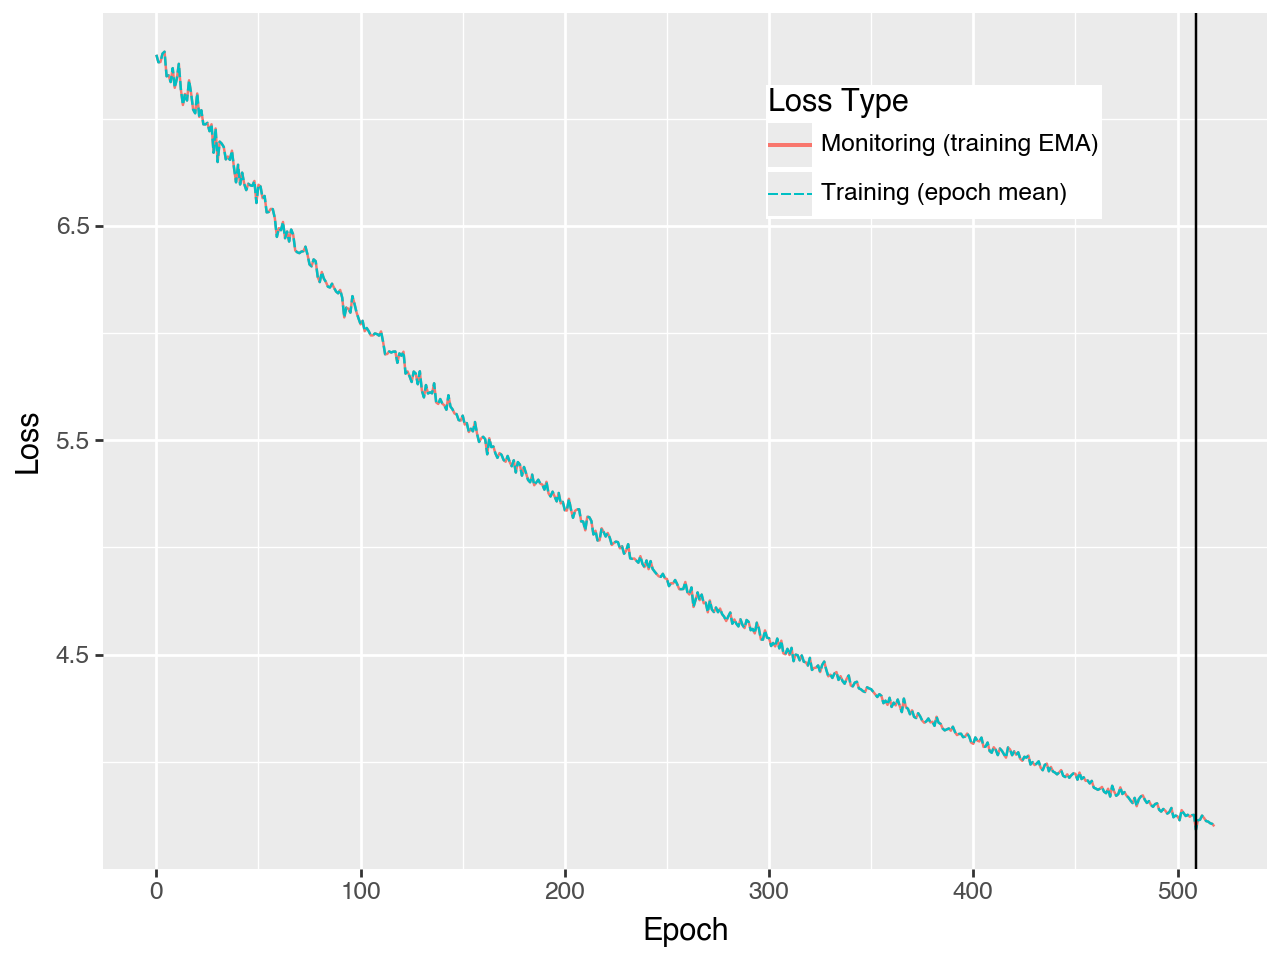

In [5]:
res.plot_loss()

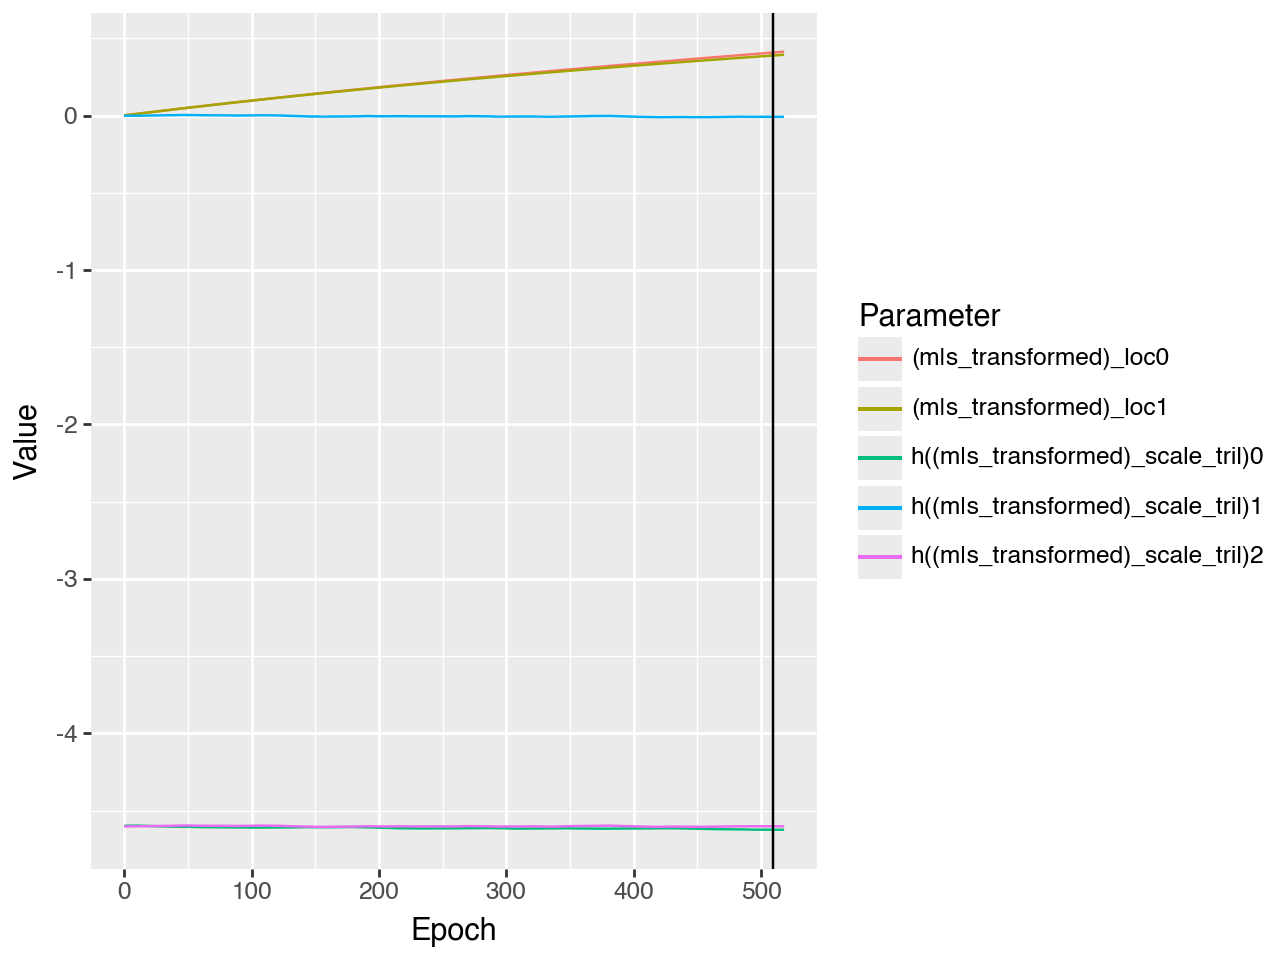

In [6]:
res.plot_params()